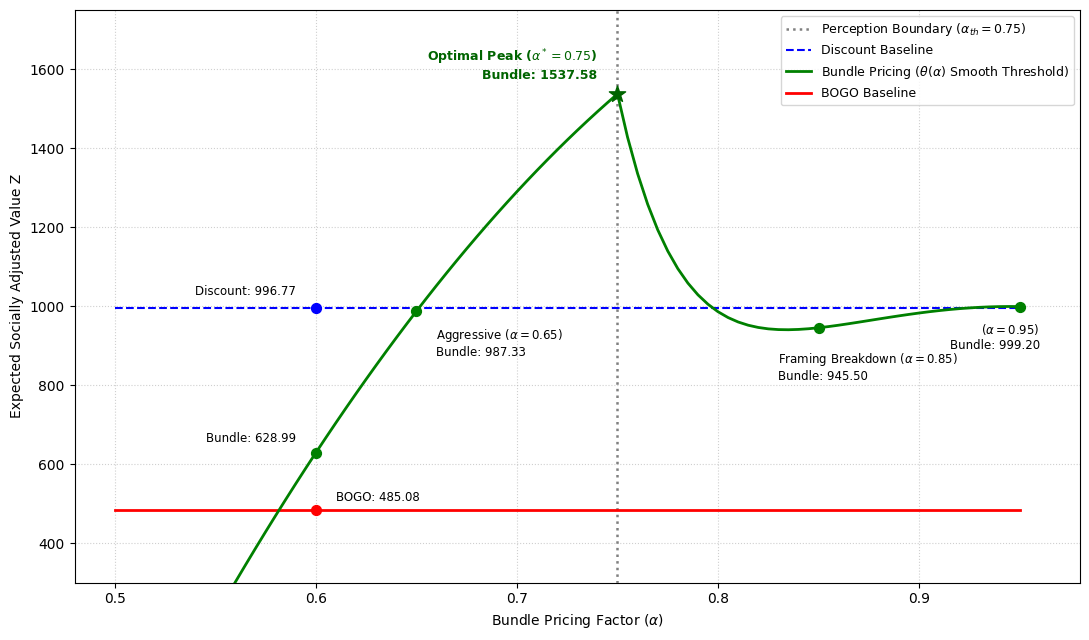

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


a, b, t, P, C, Cw, lmbda, Q = 200, 1.0, 3, 100, 40, 2, 2, 200
sigma = 20
delta_val = 2.0

P_discount_base = 95
P_bogo_base = 50

np.random.seed(42)
epsilon = np.random.normal(0, sigma, 10000)


def run_monte_carlo_precise_threshold(alpha_val):
  results = {}


  D0_disc = a - b * P_discount_base - delta_val * t
  D_stoch_disc = np.maximum(D0_disc + epsilon, 0)
  Y_disc = np.minimum(Q, D_stoch_disc)
  Z_disc = P_discount_base * Y_disc - C * Q - (Cw + lmbda) * (Q - Y_disc)
  results['Discount'] = np.mean(Z_disc)


  if alpha_val <= 0.75:
    theta_bundle = 0.10
  else:
    k_steepness = 30
    theta_bundle = 0.10 * np.exp(-k_steepness * (alpha_val - 0.75))

  P_bundle = alpha_val * P
  D0_bund = a - b * P_bundle - delta_val * t
  D_stoch_bund = np.maximum((1 + theta_bundle) * D0_bund + epsilon, 0)
  Y_bund = np.minimum(Q, D_stoch_bund)
  Z_bund = P_bundle * Y_bund - C * Q - (Cw + lmbda) * (Q - Y_bund)
  results['Bundle'] = np.mean(Z_bund)


  D0_bogo = a - b * P_bogo_base - delta_val * t
  D_stoch_bogo = np.maximum((1 + 0.20) * D0_bogo + epsilon, 0)
  Y_bogo = np.minimum(Q, D_stoch_bogo)
  Z_bogo = P_bogo_base * Y_bogo - C * Q - (Cw + lmbda) * (Q - Y_bogo)
  results['BOGO'] = np.mean(Z_bogo)

  return results



alpha_range = np.linspace(0.50, 0.95, 91)
plot_data = {'alpha': [], 'Discount': [], 'Bundle': [], 'BOGO': []}

for a_v in alpha_range:
  res = run_monte_carlo_precise_threshold(a_v)
  plot_data['alpha'].append(a_v)
  plot_data['Discount'].append(res['Discount'])
  plot_data['Bundle'].append(res['Bundle'])
  plot_data['BOGO'].append(res['BOGO'])

df_plot = pd.DataFrame(plot_data)


opt_idx = (df_plot['alpha'] - 0.75).abs().idxmin()
opt_alpha = df_plot.loc[opt_idx, 'alpha']
opt_z_bundle = df_plot.loc[opt_idx, 'Bundle']

plt.figure(figsize=(11, 6.5))


plt.axvline(
    x=0.75,
    color='gray',
    linestyle=':',
    linewidth=1.8,
    zorder=3,
    label=r'Perception Boundary ($\alpha_{th}=0.75$)',
)


plt.plot(
    df_plot['alpha'],
    df_plot['Discount'],
    label='Discount Baseline',
    color='blue',
    linestyle='--',
    zorder=4,
)
plt.plot(
    df_plot['alpha'],
    df_plot['Bundle'],
    label=r'Bundle Pricing ($\theta(\alpha)$ Smooth Threshold)',
    color='green',
    linewidth=2,
    zorder=5,
)
plt.plot(
    df_plot['alpha'],
    df_plot['BOGO'],
    label='BOGO Baseline',
    color='red',
    linewidth=2,
    zorder=4,
)


idx_060 = (df_plot['alpha'] - 0.60).abs().idxmin()
a_060 = df_plot.loc[idx_060, 'alpha']
v_disc_060 = df_plot.loc[idx_060, 'Discount']
v_bogo_060 = df_plot.loc[idx_060, 'BOGO']
v_bundle_060 = df_plot.loc[idx_060, 'Bundle']

plt.scatter([a_060], [v_disc_060], color='blue', s=50, zorder=6)
plt.text(
    a_060 - 0.01,
    v_disc_060 + 25,
    f'Discount: {v_disc_060:.2f}',
    fontsize=8.5,
    color='black',
    ha='right',
    va='bottom',
)

plt.scatter([a_060], [v_bundle_060], color='green', s=50, zorder=6)
plt.text(
    a_060 - 0.01,
    v_bundle_060 + 20,
    f'Bundle: {v_bundle_060:.2f}',
    fontsize=8.5,
    color='black',
    ha='right',
    va='bottom',
)

plt.scatter([a_060], [v_bogo_060], color='red', s=50, zorder=6)
plt.text(
    a_060 + 0.01,
    v_bogo_060 + 15,
    f'BOGO: {v_bogo_060:.2f}',
    fontsize=8.5,
    color='black',
    ha='left',
    va='bottom',
)


idx_agg = (df_plot['alpha'] - 0.65).abs().idxmin()
a_agg, v_agg = df_plot.loc[idx_agg, 'alpha'], df_plot.loc[idx_agg, 'Bundle']
plt.scatter([a_agg], [v_agg], color='green', s=50, zorder=6)
plt.text(
    a_agg + 0.01,
    v_agg - 40,
    r'Aggressive ($\alpha=0.65$)' + f'\nBundle: {v_agg:.2f}',
    fontsize=8.5,
    ha='left',
    va='top',
)


plt.scatter(
    [opt_alpha],
    [opt_z_bundle],
    color='darkgreen',
    s=150,
    zorder=10,
    marker='*',
)
plt.text(
    opt_alpha - 0.01,
    opt_z_bundle + 30,
    r'Optimal Peak ($\alpha^*='
    + f'{opt_alpha:.2f}'
    + r'$)'
    + f'\nBundle: {opt_z_bundle:.2f}',
    fontsize=9,
    fontweight='bold',
    color='darkgreen',
    ha='right',
    va='bottom',
)


idx_break85 = (df_plot['alpha'] - 0.85).abs().idxmin()
a_break85, v_break85 = (
    df_plot.loc[idx_break85, 'alpha'],
    df_plot.loc[idx_break85, 'Bundle'],
)
plt.scatter([a_break85], [v_break85], color='green', s=50, zorder=6)
plt.text(
    a_break85 - 0.02,
    v_break85 - 60,
    r'Framing Breakdown ($\alpha=0.85$)' + f'\nBundle: {v_break85:.2f}',
    fontsize=8.5,
    color='black',
    ha='left',
    va='top',
)


idx_break95 = (df_plot['alpha'] - 0.95).abs().idxmin()
a_break95, v_break95 = (
    df_plot.loc[idx_break95, 'alpha'],
    df_plot.loc[idx_break95, 'Bundle'],
)
plt.scatter([a_break95], [v_break95], color='green', s=50, zorder=6)
plt.text(
    a_break95 + 0.01,
    v_break95 - 40,
    r'($\alpha=0.95$)' + f'\nBundle: {v_break95:.2f}',
    fontsize=8.5,
    color='black',
    ha='right',
    va='top',
)


plt.xlabel(r'Bundle Pricing Factor ($\alpha$)', fontsize=10)
plt.ylabel('Expected Socially Adjusted Value Z', fontsize=10)
plt.xlim(0.48, 0.98)
plt.ylim(300, 1750)
plt.legend(loc='upper right', fontsize=9)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

plt.show()